# Dynamic-learning Rate - a way to increase and derease the learning rate based on different factors these factor are :

## 1.Time (Training-epochs).
## 2.derivation (Slope nature).
## 3.Loss-Based. 
## 4.Current Local Minimum Value. 

In [5]:
import numpy as np 
import sympy as sp
import matplotlib.pyplot as plt
import math 

# 1.Time/Training Epochs based Dymanic learning Rate

In [41]:
# Taking the same function as we have done parametric observations on with 1.Time dependent learning 
x=sp.Symbol('x')

def func():
    return sp.sin(x)*sp.exp(-x**2*0.05)

def dx():
    fun=func()
    return sp.diff(fun)

def convert():
    loss=func()
    loss_dx=dx()
    loss=sp.lambdify(x,loss,"numpy")
    ldx=sp.lambdify(x,loss_dx,"numpy")
    return loss,ldx

loss,ldx=convert()

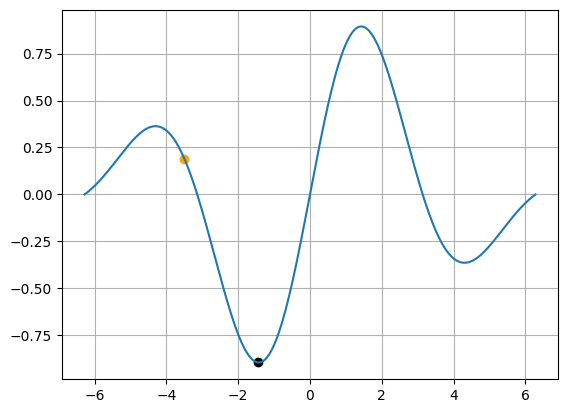

In [18]:
points=np.linspace(-2*np.pi,2*np.pi,400)

# initial_point=np.random.choice(points)
initial_point=-3.50
y=loss(points)


te=250
lr=1

fig,ax=plt.subplots()
ax.plot(points,y)
ax.scatter(initial_point,loss(initial_point),c='orange')

for i in range(1,te+1):
    lr_new=lr/i
    initial_point=initial_point-lr_new*ldx(initial_point)

ax.scatter(initial_point,loss(initial_point),c='Black')
plt.grid(True)
plt.show()

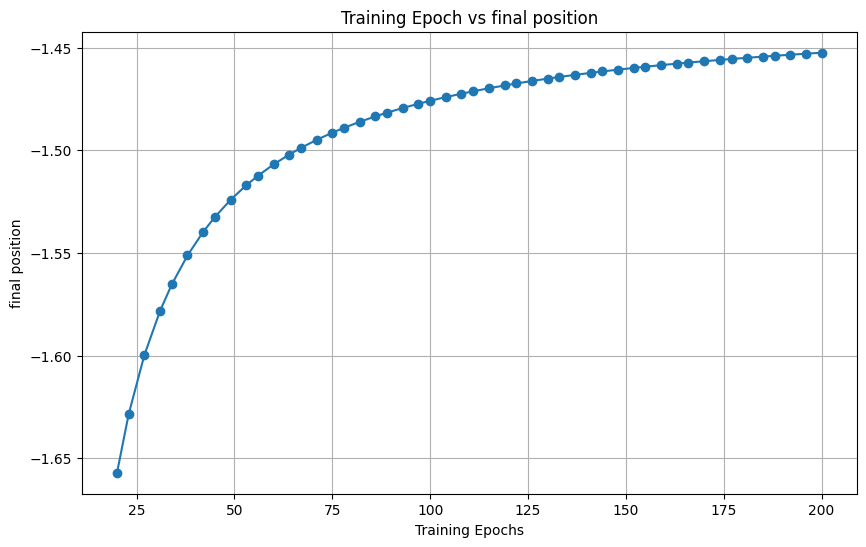

In [67]:
training_epochs = np.linspace(20, 200,50, dtype=int)
start=-3.5
global_min=-1.42
lr=1

final=np.zeros(len(training_epochs))

for index,te in enumerate(training_epochs):
    x=start
    for i in range(te):
        lr_new=lr/(i+1)
        x = x - lr_new * ldx(x)
    final[index]=x

plt.figure(figsize=(10,6))

plt.plot(
    training_epochs,
    final,
    'o-'
)
plt.xlabel("Training Epochs")
plt.ylabel("final position")
plt.title(
    "Training Epoch vs final position"
)

plt.grid(True)
plt.show()

## Very Interesting Result :-
## 1.Learning Rate should be high than normal value (normal-value=0.01)
## 2.Starting point matters 
## 3. good starting point leads to less training epoch usage 

## But it still performace is better than static learning 

## Now we see that with dynamic-learning we need alot less traning epochs which is the big win ..... but we need to find the smallest value lr and training epochs (image) for complete optimization

## After taking mutliple different value of learning rate we understand that taking very-small value is useless and taking very-large value in hope to reduce the training epochs doesn't lead us anywhere.  

## so picking optimal learning rate is solution

## Note there may be different types of learning rate decay :- Step Decay,Exponential Decay,Polynomial Decay,Cosine Annealing,Cyclical Learning Rates,Warm Restarts,Adaptive Methods (RMSProp),Adam Optimizer (Most used in Deep/Machine learning)

# 2.Gradient-Based Dynamic Learning Rate

The basic philosophy is that :: Learning rate is '∝' (inversely proportional) to gradient


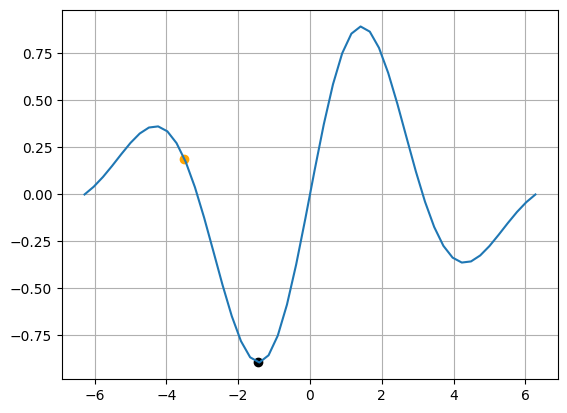

In [48]:
print('''The basic philosophy is that :: Learning rate is '∝' (inversely proportional) to gradient''')

points=np.linspace(-2*np.pi,2*np.pi)
x=-3.5

y=loss(points)

te=75
lr=0.1

fig,ax=plt.subplots()
ax.scatter(start_point,loss(start_point),c='orange')
ax.plot(points,y)

for i in range(te):
    lr_new=lr/(1+abs(ldx(x)))
    x=x-lr_new*ldx(x)

ax.scatter(x,loss(x),c="Black")

plt.grid(True)
plt.show()

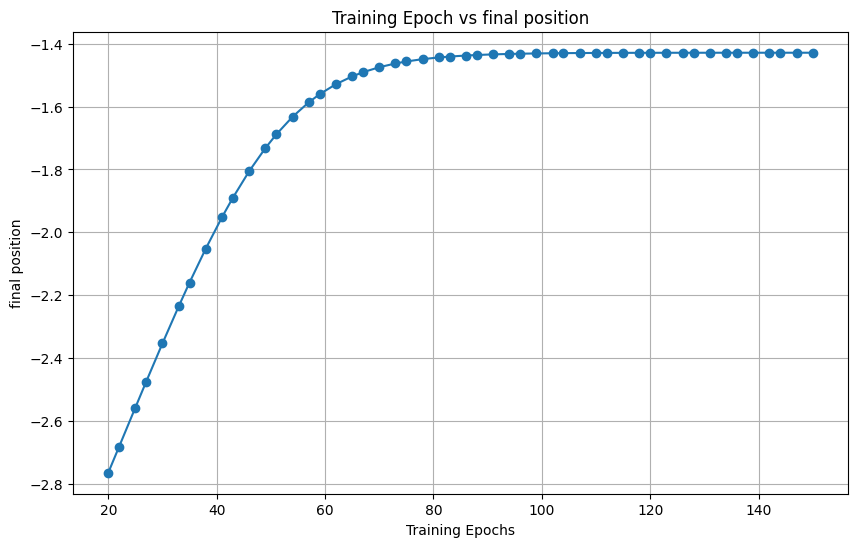

In [52]:
training_epochs = np.linspace(20, 150, 50, dtype=int)
start=-3.5
global_min=-1.42

final=np.zeros(len(training_epochs))

for index,te in enumerate(training_epochs):
    x=start
    for i in range(te):
        lr_new = lr / (1 + abs(ldx(x)))
        x = x - lr_new * ldx(x)
    final[index]=x

plt.figure(figsize=(10,6))

plt.plot(
    training_epochs,
    final,
    'o-'
)
plt.xlabel("Training Epochs")
plt.ylabel("final position")
plt.title(
    "Training Epoch vs final position"
)

plt.grid(True)
plt.show()

## With almost 80 epoch we are approaching to minima and with 100 we are there so we needed far less training epoch 

# other two are also important but best among the 4 is derivated-dynamic learning rate whihc is implemented above